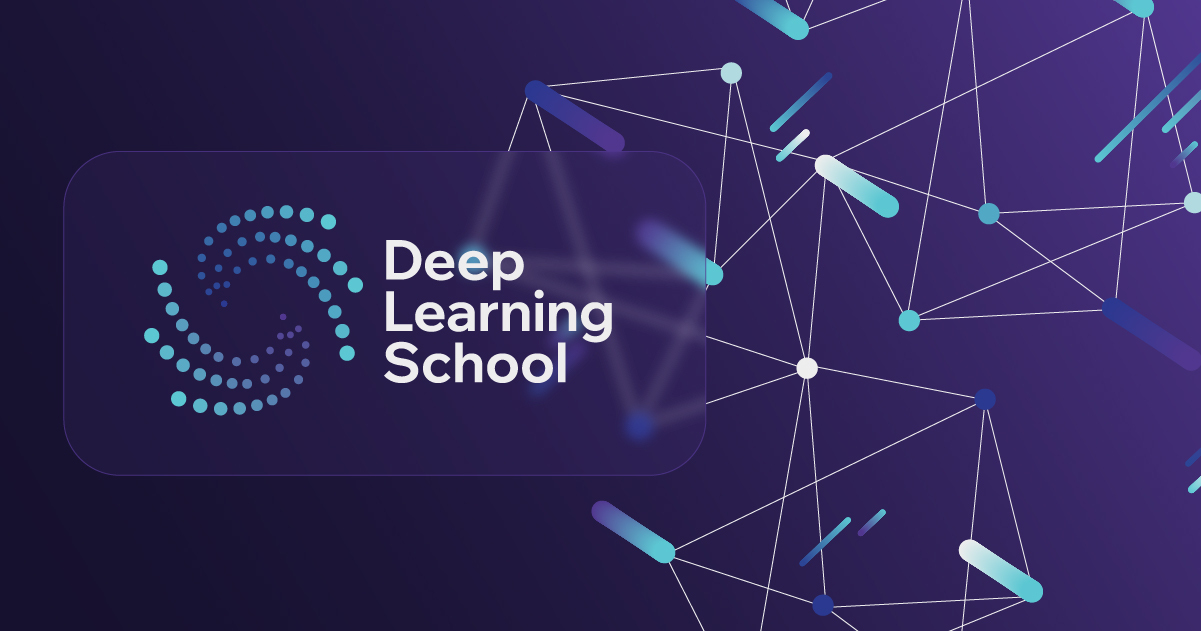

# **Школа глубокого обучения ФПМИ МФТИ**


# Семинар. ViT



В этом ноутбуке:

1. **Токенизация на патчи** — визуализируем, что трансформер «видит»
2. **Инференс предобученного ViT** — загружаем `google/vit-base-patch16-224` и получаем top-5 предсказаний на входящие картинки
3. **Карты внимания** — визуализируем, куда "смотрит" токен `[CLS]` и разбираем attention rollout
4. **Позиционные эмбеддинги учат 2D-структуру** — визуализируем cosine similarities между выученными позиционными эмбеддингами

5. **Дообучаем MLP голову на новую задачу: EuroSAT** — замораживаем ViT, обучаем только небольшую MLP-голову на основе эмбеддингов CLS и mean pooling


## Загрузка модели и данных


In [15]:
# Фиксируем версию transformers для воспроизводимого API attention.
%pip install -q "transformers==4.57.1" "torch>=2.2" torchvision pillow requests matplotlib numpy

Загружаем модель ViT:

In [16]:
import io
import requests
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import ViTImageProcessor, ViTForImageClassification

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAME = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
# attn_implementation='eager' нужен, чтобы работал output_attentions.
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",
).to(device).eval()

PATCH_SIZE = model.config.patch_size      # 16
IMG_SIZE   = model.config.image_size      # 224
GRID       = IMG_SIZE // PATCH_SIZE       # 14
N_PATCHES  = GRID * GRID                  # 196
print(f"Размер патча: {PATCH_SIZE}, размер изображения: {IMG_SIZE}, сетка: {GRID}x{GRID} = {N_PATCHES} патчей")
print(f"Размерность эмбеддингов: {model.config.hidden_size}, число слоёв: {model.config.num_hidden_layers}, число голов: {model.config.num_attention_heads}")

Device: cuda
Размер патча: 16, размер изображения: 224, сетка: 14x14 = 196 патчей
Размерность эмбеддингов: 768, число слоёв: 12, число голов: 12


In [17]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

Загрузим 4 картинки из интернета:

In [18]:
def load_image(url_or_path):
    if url_or_path.startswith(("http://", "https://")):
        r = requests.get(url_or_path, headers={"User-Agent": "vit-demo/1.0"}, timeout=20)
        r.raise_for_status()
        return Image.open(io.BytesIO(r.content)).convert("RGB")
    return Image.open(url_or_path).convert("RGB")

# Несколько демо-изображений. Можно свободно менять.
IMAGE_URLS = {
    "cat":   "https://hips.hearstapps.com/hmg-prod/images/white-cat-breeds-kitten-in-grass-67bf648a54a3b.jpg?crop=0.668xw:1.00xh;0.167xw,0&resize=640:*$0",
    "dog":   "https://hips.hearstapps.com/clv.h-cdn.co/assets/16/18/gettyimages-586890581.jpg?crop=0.668xw:1.00xh;0.219xw,0$0",
    "pizza": "https://uk.ooni.com/cdn/shop/articles/20220211142645-margherita-9920_e3a9cdac-3ff9-48e0-86f2-821e1f6c4f36.jpg?v=1790674632&width=1080$0",
    "car":   "https://media.wired.com/photos/63b8d0a771c6b526845f15a6/3:2/w_2400,h_1600,c_limit/CES-2023-PEUGEOT_INCEPTION_CONCEPT_2301CN202.jpg$0",
}

demo_images = {name: load_image(url) for name, url in IMAGE_URLS.items()}
print(f"Загружено изображений: {len(demo_images)}.")

Загружено изображений: 4.


Визуализируем загруженные картинки:

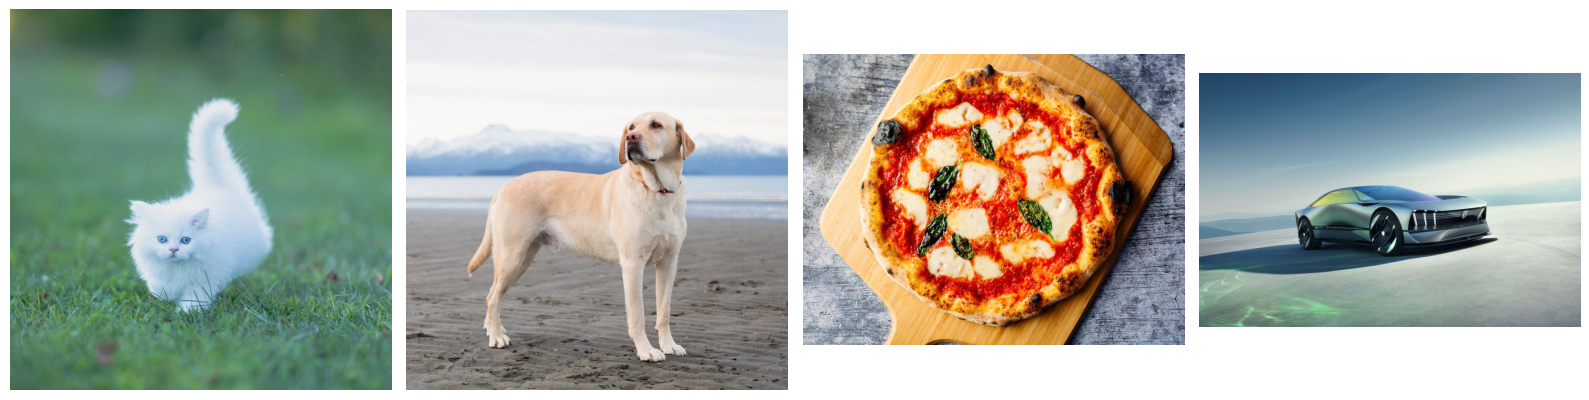

In [19]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(4 * len(demo_images), 5))
for ax, (name, img) in zip(axes, demo_images.items()):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout(); plt.show()

## Токенизация картинок на патчи

Единственная по-настоящему «новая» идея ViT: разрезать изображение на сетку патчей, а затем рассматривать эту сетку как последовательность токенов.

Ниже — код препроцессинга, который использует модель (resize до 224×224 + нормализация), затем разрезания изображения на патчи 16×16.


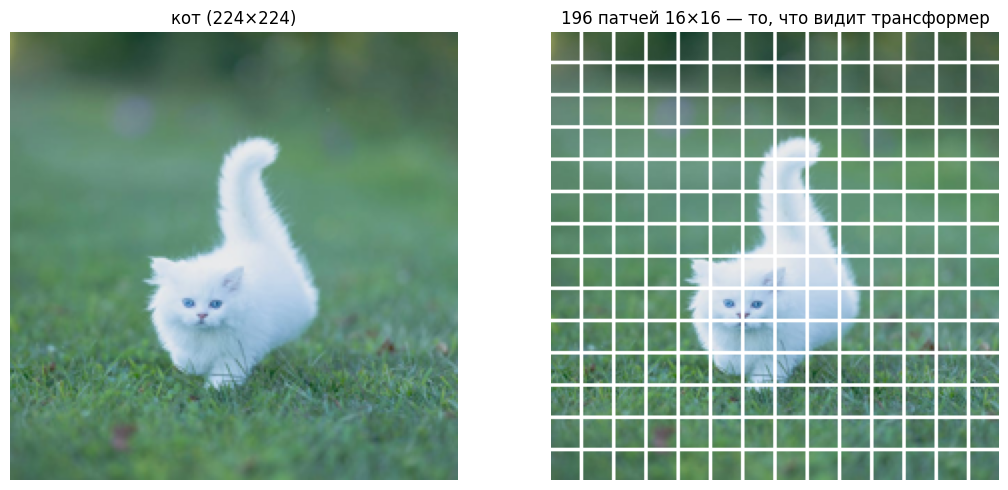

In [20]:
def preprocess_to_pixels(img):
    img = img.copy()
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img)

def to_patches(arr_224):
    """(224, 224, 3) -> сетка патчей (14, 14, 16, 16, 3)."""
    p = PATCH_SIZE
    g = GRID
    arr = arr_224.reshape(g, p, g, p, 3).transpose(0, 2, 1, 3, 4)  # (g, g, p, p, 3)
    return arr

def show_patch_grid(img, gap=2, title=""):
    arr = preprocess_to_pixels(img)
    patches = to_patches(arr)
    g, p = GRID, PATCH_SIZE
    canvas = np.ones((g * (p + gap) - gap, g * (p + gap) - gap, 3), dtype=np.uint8) * 255
    for r in range(g):
        for c in range(g):
            y0, x0 = r * (p + gap), c * (p + gap)
            canvas[y0:y0 + p, x0:x0 + p] = patches[r, c]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].imshow(arr); axes[0].set_title(f"{title} (224×224)"); axes[0].axis("off")
    axes[1].imshow(canvas); axes[1].set_title(f"196 патчей 16×16 — то, что видит трансформер"); axes[1].axis("off")
    plt.tight_layout(); plt.show()

show_patch_grid(demo_images["cat"], title="кот")

Каждый из этих 196 маленьких квадратов — это один токен. Мы разворачиваем его в вектор ($16 \times 16 \times 3 = 768$ чисел), применяем выученную линейную проекцию, добавляем выученный позиционный эмбеддинг — и получаем последовательность, готовую для трансформера.


## Инференс предобученного ViT

Загрузим модель, пропустим через неё изображение и получим top-5 предсказаний ImageNet.


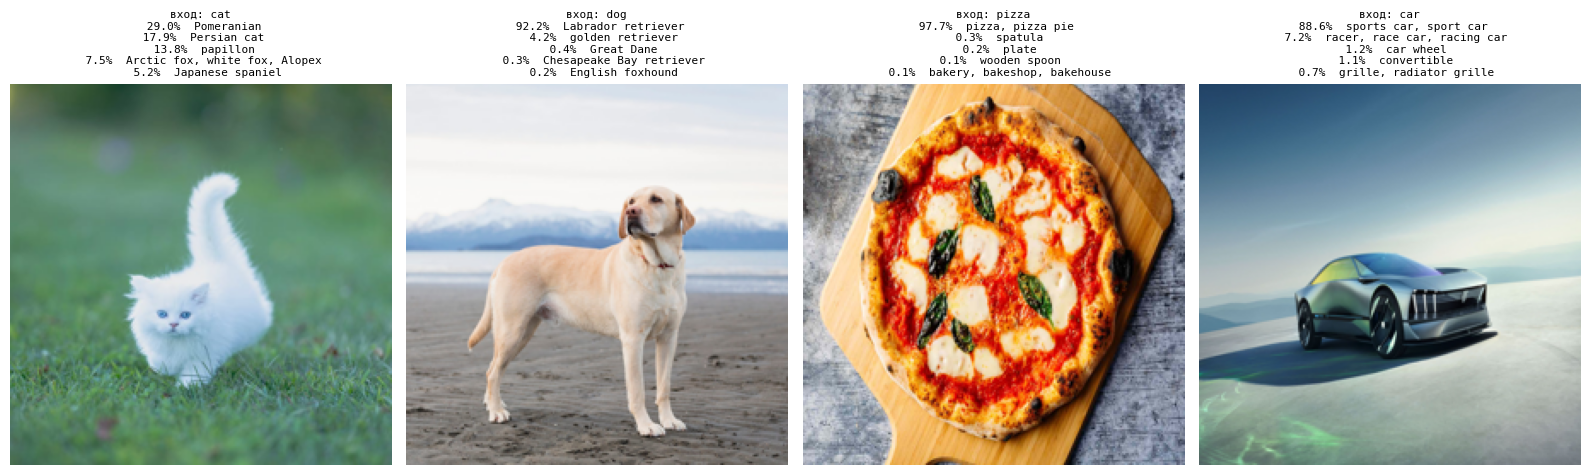

In [21]:
id2label = model.config.id2label  # Названия классов ImageNet

def predict(img, k=5):
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits[0]
    probs = torch.softmax(logits, dim=-1)
    top = torch.topk(probs, k=k)
    return [(id2label[int(i)], float(p)) for i, p in zip(top.indices, top.values)]

fig, axes = plt.subplots(1, len(demo_images), figsize=(4 * len(demo_images), 5))
for ax, (name, img) in zip(axes, demo_images.items()):
    top5 = predict(img, k=5)
    label_text = "\n".join(f"{prob*100:5.1f}%  {lbl[:30]}" for lbl, prob in top5)
    ax.imshow(preprocess_to_pixels(img))
    ax.set_title(f"вход: {name}\n{label_text}", fontsize=8, fontfamily="monospace")
    ax.axis("off")
plt.tight_layout(); plt.show()

## Карты внимания


В этой части ноутбука мы научимся строить карты внимания — визуализацию того, на какие токены обращает внимание конкретный токен. Так как для классификации картинок используется эмбеддинг токена `[CLS]`, то логично визуализировать карты внимания этого токена.

Каждый токен, включая `[CLS]`, агрегирует информацию через self-attention. Мы можем извлечь веса внимания слоев attention и посмотреть, **из каких токенов предыдущего слоя он читает информацию**.

Мы разберем два подхода к визуализции attention maps:
- прямой, когда мы визуализируем карту внимания конкретного слоя
- комплексный, который учитывает то, что токены, на которые `[CLS]` обращает внимание в слое $l$, уже содержат информацию из других токенов картинки из-за операций attention в предыдущих слоях ($1$, $\cdots$, $l-1$)

### 1. Карта внимания последнего слоя модели

Самый простой вариант получения карты внимания: берём `[CLS]` токен, и усредняем его веса attention по головам внимания со слоя $l$. Получим то, "на какие токены в среднем смотрит CLS токен на слое $l$".

Тут есть недостаток: если $l>1$, то к слою $l$ все токены уже много раз обменялись между собой информацией, поэтому то, что "`[CLS]` смотрит на токен Х" не значит, что он получает информацию именно из той части изначальной картинки, которая соответствует токену Х. Ниже мы разберем идею, как в визуализации карты внимания учесть эти зависимости от предыдущих слоев, но пока что давайте реализуем простой способ получения карты внимания:

In [23]:
@torch.no_grad()
def get_attentions(img):
    """Возвращает список attention-тензоров формы (heads, tokens, tokens), по одному на слой."""
    inputs = processor(images=img, return_tensors="pt").to(device)
    out = model(**inputs, output_attentions=True) # (num_layers, 1, heads, tokens, tokens)
    # получаем attention scores для всех слоев
    return [a[0].cpu().numpy() for a in out.attentions]  # (num_layers, heads, tokens, tokens)

def cls_attention_last_layer(attentions):
    """Последний слой, строка [CLS], усреднение по головам. Возвращает heatmap формы (14, 14)."""
    last = attentions[-1]                  # (heads, tokens, tokens)
    # усредняем по головам внимания
    avg = last.mean(axis=0)                # (tokens, tokens)
    # оставляем только внимание CLS на другие токены
    cls_to_patches = avg[0, 1:]            # убираем CLS-to-CLS, оставляем CLS->patches
    return cls_to_patches.reshape(GRID, GRID)

def overlay_attention(img, heatmap, title=""):
    arr = preprocess_to_pixels(img)
    # Увеличиваем heatmap с 14x14 до 224x224 (nearest neighbor для видимой сетки; можно было бы bilinear).
    h = np.kron(heatmap, np.ones((PATCH_SIZE, PATCH_SIZE)))
    h = (h - h.min()) / (h.max() - h.min() + 1e-8)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(arr)
    ax.imshow(h, cmap="jet", alpha=0.45)
    ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.show()

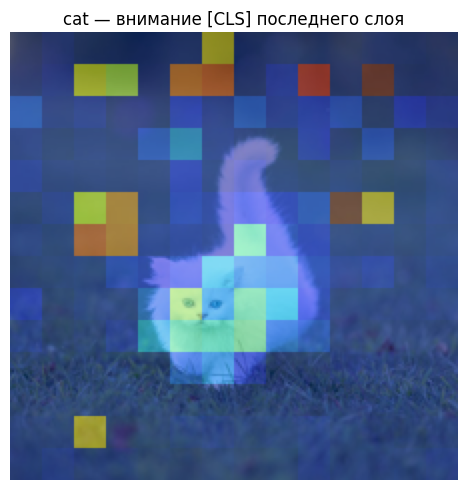

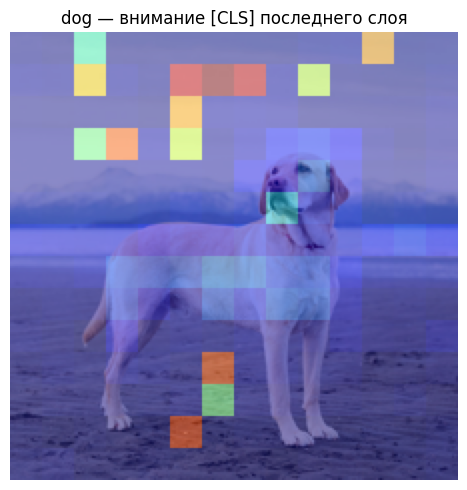

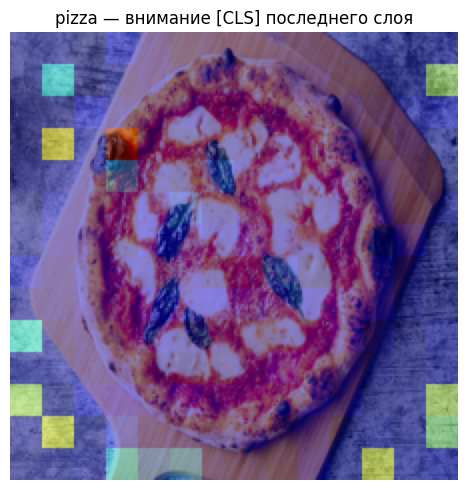

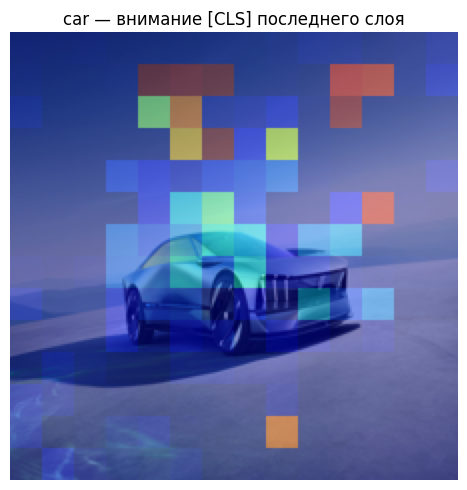

In [24]:
# Внимание последнего слоя для каждого изображения.
for name, img in demo_images.items():
    atts = get_attentions(img)
    heat = cls_attention_last_layer(atts)
    overlay_attention(img, heat, title=f"{name} — внимание [CLS] последнего слоя")

### 2. Attention rollout



**Проблема:** в слое $l$ `[CLS]` читает информацию не из исходных токенов картинки, а из токенов после слоя $l-1$. Если $l>1$, то любой токен к этому моменту может содержать информацию со всего изображения, и `[CLS]`, "обращая внимания" на какой-то конкретный токен, может на самом деле считывать из него информацию из другой части изображения, а не из той, которая соответствует этому токену. Поэтому простая визуализация карты внимания слоя $l$ отражает то, на какие части картинки смотрит `[CLS]`, очень неточно.

**Архитектурное приближение:**
Сейчас мы попробуем учесть зависимости между слоями в нашей визуализации карты внимания. Между каждыми слоями self-attention находятся несколько других слоев: два `layer norm`, `MLP`. Учитывать то, как внимание каждого токена трансформируется под действием всех этих слоев, было бы довольно сложно. Поэтому для простоты вычислений в статье [Abnar & Zuidema, 2020 — Quantifying Attention Flow in Transformers](https://aclanthology.org/2020.acl-main.385/) предложили идею упрощения. Она состоит в двух вещах:
- приблизить все слои кроме self-attention, матрицами identity, т.е. считать, что этих слоев нет
- усреднить внимание каждого токена в каждом attention слое по всем головам внимания, получая то, куда "в среднем" смотрит токен на этом слое

Что тогда получится:

Обозначим за $h^{l-1}_j$ эмбеддинг токена номер $j$ на входе в слой номер $l$.
Возьмем карту внимания слоя $l$ и усредним ее по головам внимания этого слоя. Пусть $A^l[i,j]$ — значение этой матрицы внимания между токенами $i$ и $j$: то есть, $A^l[i,j]$ — вес, с которым токен $i$ слоя $l$ читает токен $j$ слоя $l-1$.

При условии нашего упрощения (считаем все слои `layer norm` и `MLP`, а также матрицу $W_V$ получения value токена тождественными преобразованиями), с учетом residual connection эмбеддинг токена номер $j$ на выходе слоя $l$ будет $$h^{l}_j = h^{l-1}_j + \sum_{i = 1}^n A^l[j,i]h^{l-1}_i$$

Заметим теперь, что если $I$ — единичная матрица, то $1 = \sum_{k=1}^n I[i,k]$, где $I[i,k]$ — элемент строки $i$ и столбца $k$. И тогда $h^{l-1}_j$  можно занести под знак суммы:

$$h^{l}_j = \left( \sum_{i = 1}^n I[j, i]h^{l-1}_i + A^l[j,i]h^{l-1}_i \right)$$

Тогда для слоя $l+1$:

$$h_j^{l+1} = h^{l}_j + \sum_{i = 1}^n A^l[j,i]h^{l}_i =$$

$$ = \left( \sum_{i = 1}^n I[j, i]h^{l-1}_i + A^l[j,i]h^{l-1}_i \right) + \sum_{i = 1}^n A^{l+1}[j,i] \left(\sum_{k = 1}^n \left( I[i, k]h_k^{l-1} + A^l[i,k]h^{l-1}_k \right) \right) = $$

$$ = \left( \sum_{i = 1}^n h^{l-1}_i (I[j, i] + A^l[j,i]) \right) + \sum_{i = 1}^n A^{l+1}[j,i] \left(\sum_{k = 1}^n h_k^{l-1}\left( I[i, k] + A^l[i,k] \right) \right) $$

Обозначим $$B^l[i,j] = A^l[i,j]+I[i,j]$$, получим:

$$h_j^{l+1} = \left( \sum_{i = 1}^n h^{l-1}_i B^l[j,i] \right) + \sum_{i = 1}^n A^{l+1}[j,i] \left(\sum_{k = 1}^n h_k^{l-1}B^l[i,k] \right)$$

$$=  \sum_{i = 1}^n I[j, i] \left( \sum_{k = 1}^n h^{l-1}_k B^l[j,k] \right) + \sum_{i = 1}^n A^{l+1}[j,i] \left(\sum_{k = 1}^n h_k^{l-1}B^l[i,k] \right)$$

$$= \sum_{i = 1}^n \left(  I[j, i] + A^{l+1}[j,i] \right) \left(\sum_{k = 1}^n h_k^{l-1}B^l[i,k] \right) =$$

$$= \sum_{i = 1}^n B^{l+1}[j, i] \left(\sum_{k = 1}^n B^l[i,k] h_k^{l-1}\right) = $$

$$= \sum_{i = 1}^n \sum_{k = 1}^n \left( B^{l+1}[j, i] B^l[i,k] \right)h_k^{l-1} = $$

Теперь положим $h_k^{l-1} =1 $ (т.е. $h^{l-1}$ единичным вектором — еще одно упрощение), и тогда получим простое выражение для $h^{l+1}$

$$ h^{l+1} = B^{l+1}B^l$$


Разворачивая дальше, от слоя к слою, в итоге получим связь:

$$h^{n} = B^{n} \dots B^1$$

Интуитивно, $B^l$ выражает сложение residual stream с выходом аттеншена, и полученные выражения для всех слоев перемножаются. Если снова записать $B^l = A^l + I$ и раскрыть скобки в выражении $h^{n} = (A^n + I) \dots (A^1 + I)$, то каждое слагаемое будет соответствовать одному из путей исходного вектора $h^0$ до последнего слоя $h^n$ по residual stream в нашей модели упрощенной сети.

Ниже — иллюстрация нашей "упрощенной модели сети", зеленым обозначен один из возможных путей эмбеддинга по residual stream


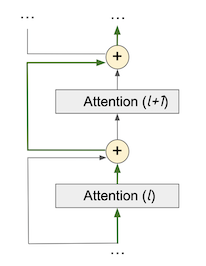

Теперь реализуем attention rollout:

In [25]:
def rollout_matrix(attentions):
    """result[i, j]: связь выходного токена i с входным j в упрощённой модели.

    attentions идут от первого слоя к последнему; каждый имеет форму (heads, T, T).
    Строка attention = получатель (query), столбец = источник информации (key/value).
    """
    result = np.eye(attentions[0].shape[-1])   # перед всеми attention слоями матрица внимания единичная
    for a in attentions:
        a = a.mean(axis=0)                     # берем среднее по головам внимания
        b = a + np.eye(a.shape[-1])            # B = A + I
        b = b / b.sum(axis=-1, keepdims=True)
        result = b @ result                    # result_l = B_l @ result_{l-1}
    return result

def attention_rollout(attentions):
    """Связь финального CLS с входными патчами; heatmap (GRID, GRID)."""
    result = rollout_matrix(attentions)
    return result[0, 1:].reshape(GRID, GRID)   # получаем матрицу внимания для CLS токена по всем остальным патчам


Получим матрицы внимания `[CLS]` токена последнего слоя для наших четырех картинок:

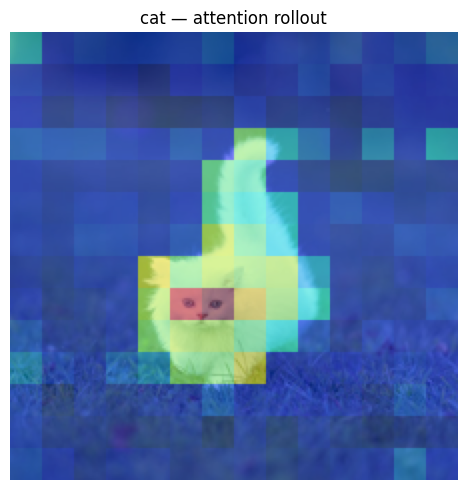

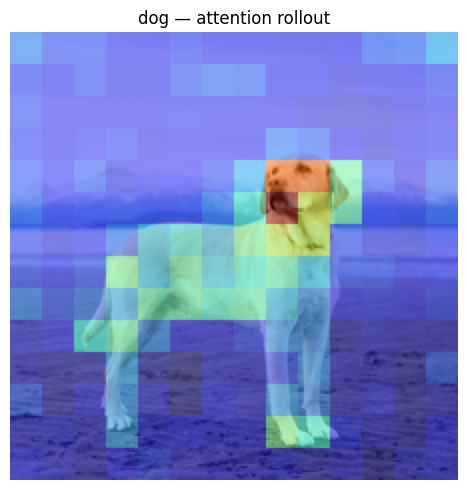

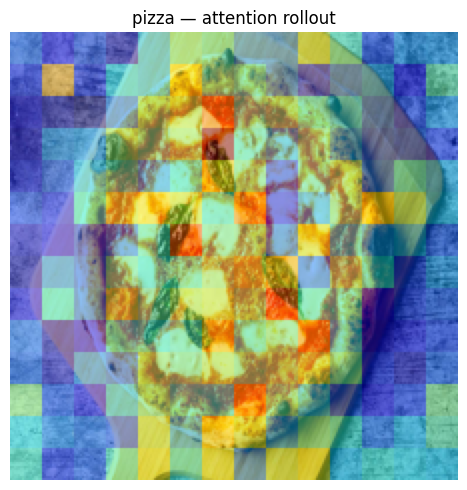

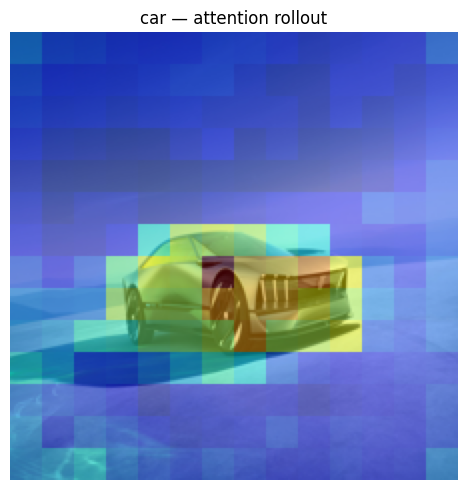

In [26]:
for name, img in demo_images.items():
    atts = get_attentions(img)
    heat = attention_rollout(atts)
    overlay_attention(img, heat, title=f"{name} — attention rollout")

**Важно:**

Мы видим, что яркие области полученной карты во многом часто совпадают с положением объекта на картинке. Это кажется логичным и дает представление, что механизм внимания работает "как надо" и действительно смотрит на патчи обекта, классифицируя этот объект. Но идея attention rollout сделана для приближенной модели: мы не учитываем вклад слоев `layer norm`, `MLP`, $W_v$, и разницу между ничальными векторами эмбеддингов патчей. Поэтому то, что мы видим как результат attention rollout — только грубое приближение того, что на самом деле происходит в модели.

### Карты внимания по слоям — сначала локальное, затем глобальное

До сих пор мы смотрели на внимание *последнего* слоя. Давайте теперь проверим, что ViT учит **локальное внимание в ранних слоях и глобальное внимание в поздних слоях**, восстанавливая CNN-подобный inductive bias из данных.

Посмотрим на это эмпирически. Сделаем две вещи:

1. Выберем одно изображение и один **референсный патч**, а затем визуализируем внимание *из этого патча* во всех 12 слоях.
2. Построим **среднюю дистанцию внимания** для каждого слоя × головы — количественную метрику, использованную в статье ViT (Fig. 6).


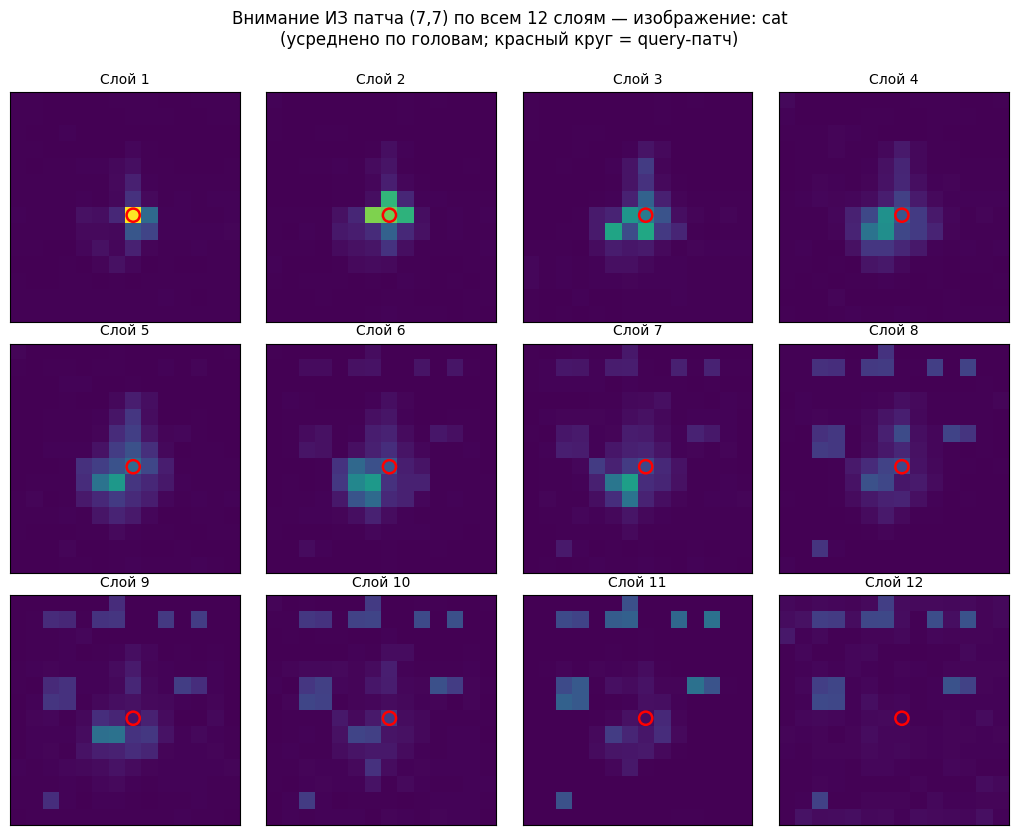

In [27]:
# Выберем одно изображение и один референсный патч. Для каждого слоя покажем внимание
# *из* этого патча *к* каждому другому патчу как heatmap 14×14.

REF_R, REF_C = 7, 7         # центральный патч — попробуйте поменять, например на (3, 3) для верхнего левого участка
DEMO_KEY = "cat"            # какое демо-изображение анализировать

img = demo_images[DEMO_KEY]
atts = get_attentions(img)  # список (heads, tokens, tokens), по одному на слой
n_layers = len(atts)
ref_idx = 1 + REF_R * GRID + REF_C  # +1, чтобы пропустить [CLS]

per_layer_maps = []
for a in atts:
    avg_heads = a.mean(axis=0)              # (tokens, tokens)
    row = avg_heads[ref_idx, 1:]            # внимание из референсного патча ко всем 196 патчам
    per_layer_maps.append(row.reshape(GRID, GRID))

# Общая цветовая шкала, чтобы слои было удобно сравнивать визуально.
vmax = max(m.max() for m in per_layer_maps)

cols = 4
rows = (n_layers + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.6 + 0.5))
axes = np.atleast_2d(axes)
for i, ax in enumerate(axes.ravel()):
    if i < n_layers:
        ax.imshow(per_layer_maps[i], cmap="viridis", vmin=0, vmax=vmax)
        ax.scatter([REF_C], [REF_R], s=90, edgecolors="red", facecolors="none", linewidths=1.8)
        ax.set_title(f"Слой {i+1}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Внимание ИЗ патча ({REF_R},{REF_C}) по всем {n_layers} слоям — изображение: {DEMO_KEY}\n"
             f"(усреднено по головам; красный круг = query-патч)",
             fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

**Что видим:**

- **Ранние слои** (1–3): яркая область концентрируется рядом с query-патчем — внимание в основном **локальное**, похоже на маленькое receptive field в CNN.
- **Средние слои**: яркая область расширяется, иногда захватывая другие части объекта.
- **Поздние слои** (10–12): внимание становится **глобальным** — модель распределяет внимание по семантически связанным патчам в любой части изображения.

Тот же тренд виден на следующем графике, но уже количественно.


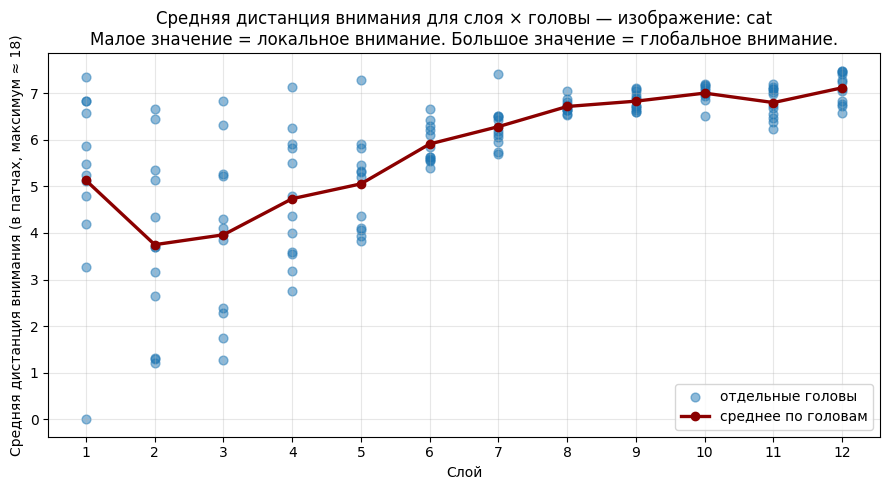

In [28]:
# Средняя дистанция внимания для каждого слоя × головы.
# В статье ViT (Dosovitskiy et al., 2021, Fig. 6) эта метрика используется, чтобы характеризовать,
# насколько каждая голова смотрит локально или глобально. Здесь мы её воспроизводим.

# Попарная дистанция между патчами в единицах сетки (считаем патчи сеткой 14×14).
coords = np.array([(r, c) for r in range(GRID) for c in range(GRID)], dtype=np.float32)
dist_matrix = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)  # (196, 196)

def mean_attention_distance(attentions):
    """Для каждого слоя и головы: weighted mean distance от query-патча до патчей, на которые направлено внимание."""
    rows = []
    for a in attentions:                                  # (heads, tokens, tokens)
        patch_attn = a[:, 1:, 1:]                         # убираем строку и столбец CLS → (heads, 196, 196)
        patch_attn = patch_attn / (patch_attn.sum(axis=-1, keepdims=True) + 1e-12)
        weighted = (patch_attn * dist_matrix[None]).sum(axis=-1)  # (heads, queries)
        rows.append(weighted.mean(axis=-1))               # усредняем по query-патчам → (heads,)
    return np.array(rows)                                  # (n_layers, n_heads)

dist_arr = mean_attention_distance(atts)
n_layers, n_heads = dist_arr.shape
layer_x = np.arange(1, n_layers + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for h in range(n_heads):
    ax.scatter(layer_x, dist_arr[:, h], color="tab:blue", alpha=0.5, s=40,
               label="отдельные головы" if h == 0 else None)
ax.plot(layer_x, dist_arr.mean(axis=-1), color="darkred", lw=2.4, marker="o",
        label="среднее по головам")

ax.set_xlabel("Слой")
ax.set_ylabel("Средняя дистанция внимания (в патчах, максимум ≈ 18)")
ax.set_title(f"Средняя дистанция внимания для слоя × головы — изображение: {DEMO_KEY}\n"
             "Малое значение = локальное внимание. Большое значение = глобальное внимание.")
ax.set_xticks(layer_x)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Что видим:**

- Синие точки = одна точка на голову в каждом слое; красная линия = среднее по головам.
- **Ранние слои** смешанные: некоторые головы смотрят очень локально (дистанция ≈ 2–3 патча), а другие уже смотрят глобально. То есть модель использует смесь CNN-подобного и transformer-подобного поведения уже с первого слоя.
- **Поздние слои** сдвигают почти все головы к глобальному вниманию.
- Максимум по оси y около 18 (диаметр сетки патчей 14×14). Голова с дистанцией ≈ 6 смотрит примерно на всё изображение.

По сути, это Figure 6 из статьи ViT, воспроизведённая для одного изображения. Такая же форма возникает при усреднении по многим изображениям — переход от локального к глобальному является свойством обученной модели, а не конкретного входа.


### Как `[CLS]` агрегирует информацию по слоям

Визуализация patch-to-patch выше показывает, что обычные патчи сначала локальны, а затем становятся глобальными. Следует ли токен `[CLS]` тому же паттерну?

Построим внимание `[CLS]` ко всем патчам на каждом слое.


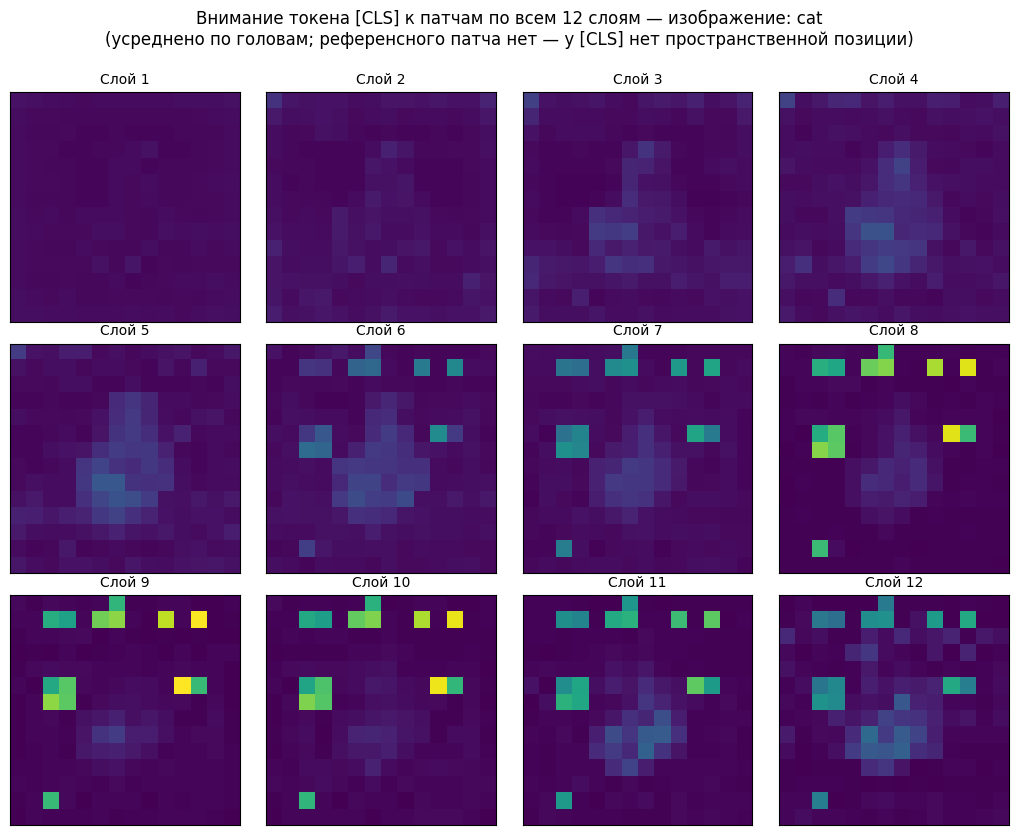

In [29]:
# Такая же визуализация по слоям, но для токена [CLS] вместо патча.
# Использует `atts`, `n_layers` и `DEMO_KEY` из ячеек выше.

cls_per_layer_maps = []
for a in atts:                                  # (heads, tokens, tokens) per layer
    avg_heads = a.mean(axis=0)                  # (tokens, tokens)
    cls_row = avg_heads[0, 1:]                  # CLS → все 196 патчей
    cls_per_layer_maps.append(cls_row.reshape(GRID, GRID))

vmax_cls = max(m.max() for m in cls_per_layer_maps)

cols = 4
rows_n = (n_layers + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 2.6, rows_n * 2.6 + 0.5))
axes = np.atleast_2d(axes)
for i, ax in enumerate(axes.ravel()):
    if i < n_layers:
        ax.imshow(cls_per_layer_maps[i], cmap="viridis", vmin=0, vmax=vmax_cls)
        ax.set_title(f"Слой {i+1}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Внимание токена [CLS] к патчам по всем {n_layers} слоям — изображение: {DEMO_KEY}\n"
             "(усреднено по головам; референсного патча нет — у [CLS] нет пространственной позиции)",
             fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

**Что видим:**

- Сравните с patch-to-patch визуализацией выше: `[CLS]` **уже широко распределяет внимание даже на слое 1**. Он не следует тому же паттерну «от локального к глобальному», что обычные патчи. Это логично: `[CLS]` — *summary*-токен. Его задача — агрегировать информацию отовсюду; у него нет пространственной позиции, к которой можно привязаться.
- В **поздних слоях** внимание `[CLS]` обычно становится более *избирательным* — концентрируется на нескольких патчах, которые, видимо, содержат в себе релевантную информацию тому, к какому классу принадлежит объект.

В целом, внимание патчей картинки распределяется боле локально в первых слоях сети, и более глобально в поздних слоях сети. Это похоже на иерархичность CNN. Внимание `[CLS]` токена ведёт себя довольно глобально уже с самых первых слоев.


---

## Позиционные эмбеддинги учат 2D-структуру

ViT использует **1D выученный позиционный эмбеддинг** — просто один вектор для каждой позиции (от 0 до 196). В нём *нет* встроенного понятия «строки» или «столбца».

Тем не менее, если посчитать cosine similarity между выученными позиционными эмбеддингами и визуализировать её, мы увидим, что **каждая позиция наиболее похожа на своих 2D-пространственных соседей**.

Модель восстановила 2D-сетку с нуля, только по обучающим данным.


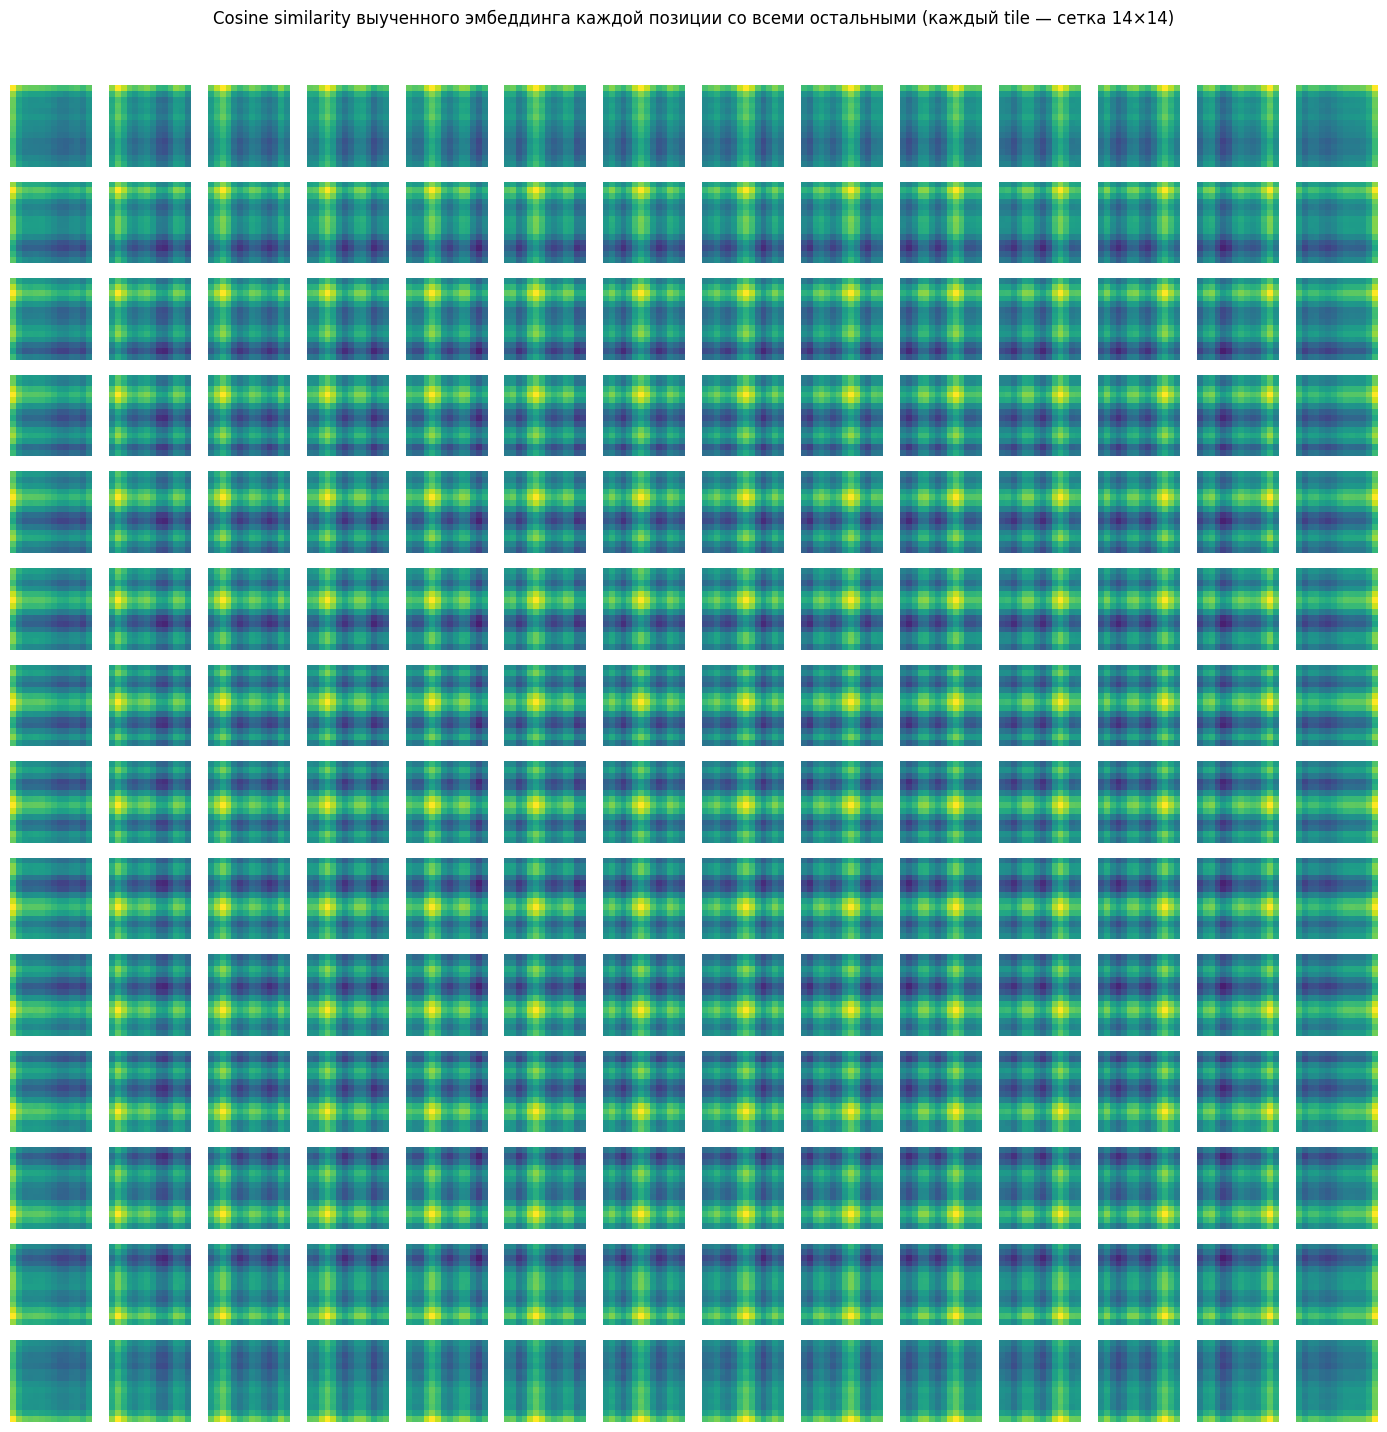

In [30]:
pos_emb = model.vit.embeddings.position_embeddings.detach().cpu().numpy()[0]  # (197, 768)
patch_pos = pos_emb[1:]  # drop the [CLS] position; now (196, 768)

# L2-нормализуем, затем считаем все попарные cosine similarities.
norm = patch_pos / np.linalg.norm(patch_pos, axis=-1, keepdims=True)
sim = norm @ norm.T  # (196, 196)

# Для каждой позиции разворачиваем её 196 similarities обратно в сетку 14x14.
sim_grids = sim.reshape(GRID, GRID, GRID, GRID)

fig, axes = plt.subplots(GRID, GRID, figsize=(GRID, GRID))
for r in range(GRID):
    for c in range(GRID):
        ax = axes[r, c]
        ax.imshow(sim_grids[r, c], cmap="viridis", vmin=-1, vmax=1)
        ax.axis("off")
fig.suptitle("Cosine similarity выученного эмбеддинга каждой позиции со всеми остальными (каждый tile — сетка 14×14)",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

**Что видим:**

- Каждый tile $(r, c)$ показывает яркое пятно в позиции $(r, c)$ — и это пятно плавно затухает к её 2D-соседям.
- Яркая область **пространственно локализована**, а не, например, выглядит как горизонтальная полоса, соответствующая 1D-порядку. Модель восстановила структуру 2D-сетки с нуля.

Увеличим одну позицию, чтобы увидеть это конкретнее:


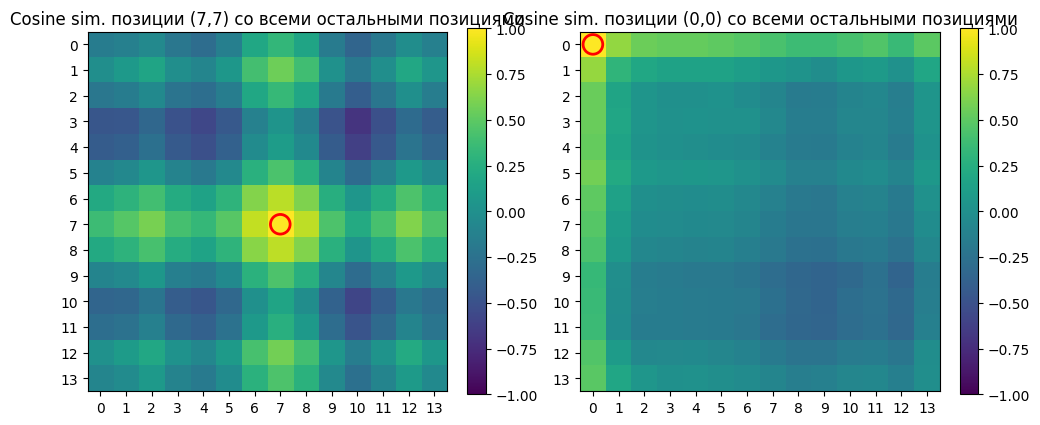

In [31]:
# Подсветим одну позицию (центр изображения).
r, c = 7, 7
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

im = axes[0].imshow(sim_grids[r, c], cmap="viridis", vmin=-1, vmax=1)
axes[0].set_title(f"Cosine sim. позиции ({r},{c}) со всеми остальными позициями")
axes[0].scatter([c], [r], s=200, edgecolors="red", facecolors="none", linewidths=2)
axes[0].set_xticks(range(GRID)); axes[0].set_yticks(range(GRID))
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Угол для контраста.
r2, c2 = 0, 0
im = axes[1].imshow(sim_grids[r2, c2], cmap="viridis", vmin=-1, vmax=1)
axes[1].set_title(f"Cosine sim. позиции ({r2},{c2}) со всеми остальными позициями")
axes[1].scatter([c2], [r2], s=200, edgecolors="red", facecolors="none", linewidths=2)
axes[1].set_xticks(range(GRID)); axes[1].set_yticks(range(GRID))
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout(); plt.show()

**Горячая точка следует за позицией** — и плавно затухает вдоль обеих осей. Модель фактически выучила 2D-евклидово расстояние без вручную заданного prior.


---

## Обучение MLP поверх замороженных ViT-эмбеддингов на новую задачу

В этой части мы используем предобученный ViT как **готовый экстрактор эмбеддингов** для дообучения на новую задачу. Мы будем получать эмбеддинги `[CLS]` токена / pooled эмбеддинги патчей из последнего слоя замороженного ViT, и обучим новую `MLP` голову на основе этих эмббедингов решать новую задачу классификации. Мы будем решать задачу классификации **EuroSAT RGB**, классы которой — леса, реки, жилые районы, сельскохозяйственные территории и т.д.


**Данные:** [EuroSAT — Helber et al.](https://github.com/phelber/EuroSAT), 27 000 RGB-изображений 64×64, 10 классов. Скачиваем [официальный RGB-архив с Zenodo](https://zenodo.org/records/7711810) (около 95 MB). В этом ноутбуке мы будем использовать небольшую сбалансированную подвыборку этих данных для ускорения вычислений.

**План:**
1. Делим изображения на train / validation / test.
2. Один раз пропускаем их через замороженный ViT и сохраняем эмбеддинги последнего слоя
3. Обучаем маленькую MLP на готовых векторах, подбирая гиперпараметры на валидации
4. Оцениваем выбранную модель на test и смотрим, где модель ошибается.


In [33]:
import copy
import hashlib
import json
import time
from pathlib import Path

import transformers
from torch import nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_and_extract_archive
from tqdm.auto import tqdm

SEED = 42
EMBEDDING_MODES = ("cls", "mean")   # вариант получения итогового эмбеддинга картинки

TRAIN_PER_CLASS = 80
VAL_PER_CLASS = 20
TEST_PER_CLASS = 20

EXTRACT_BATCH_SIZE = 16
HEAD_BATCH_SIZE = 64

HIDDEN_DIM = 128
EPOCHS = 20
LEARNING_RATE = 1e-3

DATA_DIR = Path("./eurosat")
CACHE_DIR = Path("vit_embedding_cache")
FORCE_RECOMPUTE = False

model.eval()
model.requires_grad_(False)
model.zero_grad(set_to_none=True)
print("Обучаемых параметров в исходном ViT:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))
print(f"Примеры на класс: train={TRAIN_PER_CLASS}, val={VAL_PER_CLASS}, test={TEST_PER_CLASS}")

Обучаемых параметров в исходном ViT: 0
Примеры на класс: train=80, val=20, test=20


### Загрузка и подготовка данных

100%|██████████| 94.7M/94.7M [00:46<00:00, 2.05MB/s]


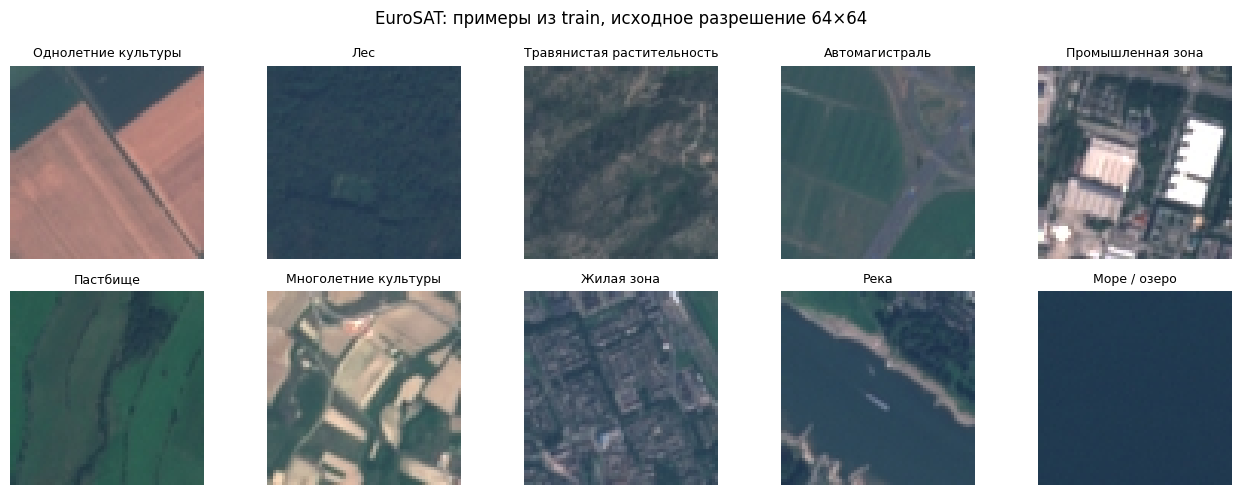

In [34]:
# Скачивание
if not DATA_DIR.is_dir():
    download_and_extract_archive(
        "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip",
        download_root=str(DATA_DIR),
        filename="EuroSAT_RGB.zip",
        md5="f46e308c4d50d4bf32fedad2d3d62f3b",
    )
dataset = ImageFolder(DATA_DIR/'EuroSAT_RGB')   # PIL RGB; resize/normalization делает processor

class_names = dataset.classes
NUM_CLASSES = len(class_names)

assert NUM_CLASSES == 10
names_ru = {
    "AnnualCrop": "Однолетние культуры", "Forest": "Лес",
    "HerbaceousVegetation": "Травянистая растительность", "Highway": "Автомагистраль",
    "Industrial": "Промышленная зона", "Pasture": "Пастбище",
    "PermanentCrop": "Многолетние культуры", "Residential": "Жилая зона",
    "River": "Река", "SeaLake": "Море / озеро",
}
class_titles = [names_ru[name] for name in class_names]

# поделим данные на train/val/test, сбалансировав по классам
targets = np.asarray(dataset.targets)
rng = np.random.default_rng(SEED)
split_indices = {name: [] for name in ("train", "val", "test")}
counts = [TRAIN_PER_CLASS, VAL_PER_CLASS, TEST_PER_CLASS]
assert all(n > 0 for n in counts)
for class_id in range(NUM_CLASSES):
    ids = rng.permutation(np.flatnonzero(targets == class_id))
    assert sum(counts) <= len(ids), "Недостаточно изображений для такого разбиения"
    offset = 0
    for split, count in zip(split_indices, counts):
        split_indices[split].extend(ids[offset:offset + count].tolist())
        offset += count

# визуализируем некоторые примеры
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for class_id, ax in enumerate(axes.ravel()):
    idx = next(i for i in split_indices["train"] if targets[i] == class_id)
    ax.imshow(dataset[idx][0])
    ax.set_title(class_titles[class_id], fontsize=9)
    ax.axis("off")
fig.suptitle("EuroSAT: примеры из train, исходное разрешение 64×64")
plt.tight_layout(); plt.show()

### Получаем эмбеддинги из модели

Теперь для всех картинок нужно получить `model.vit(...).last_hidden_state` — выходные токены **после финального LayerNorm**, размерности $(batch\_size,197,768)$. Первый из 197 токенов — `[CLS]`, остальные — токены патчей картинки

Далее получаем два вариант финального эмбеддинга для каждой картинки — эмбеддинг `[CLS]` токена или усредненные эмбеддинги патчей картинки:

$$
z_{\mathrm{CLS}}=H[:,0,:],\qquad
z_{\mathrm{mean}}=\frac1{196}\sum_{i=1}^{196}H[:,i,:].
$$


In [35]:
def collate_images(batch):
    images, labels = zip(*batch)
    pixels = processor(images=list(images), return_tensors="pt")["pixel_values"]
    return pixels, torch.tensor(labels, dtype=torch.long)

@torch.no_grad()
def extract_embeddings(indices, split):
    model.eval()
    loader = DataLoader(Subset(dataset, indices), batch_size=EXTRACT_BATCH_SIZE,
                        shuffle=False, num_workers=0, collate_fn=collate_images)
    chunks = {"cls": [], "mean": [], "labels": []}

    for pixels, labels in tqdm(loader, desc=f"ViT: {split}"):
        tokens = model.vit(
            pixel_values=pixels.to(device),
            output_attentions=False, output_hidden_states=False, return_dict=True,
        ).last_hidden_state

        chunks["cls"].append(tokens[:, 0, :].detach().float().cpu())
        chunks["mean"].append(tokens[:, 1:, :].mean(dim=1).detach().float().cpu())
        chunks["labels"].append(labels)

    result = {name: torch.cat(parts) for name, parts in chunks.items()}
    return result

In [36]:
if CACHE_DIR.exists():
    features = torch.load(CACHE_DIR, map_location="cpu", weights_only=True)
    print("Готовые эмбеддинги загружены из", CACHE_DIR)
else:
    features = {split: extract_embeddings(ids, split) for split, ids in split_indices.items()}
    torch.save(features, CACHE_DIR)
    print("Эмбеддинги сохранены в", CACHE_DIR)

for split, data in features.items():
    print(split, "CLS:", tuple(data["cls"].shape), "mean:", tuple(data["mean"].shape))

ViT: train:   0%|          | 0/50 [00:00<?, ?it/s]

ViT: val:   0%|          | 0/13 [00:00<?, ?it/s]

ViT: test:   0%|          | 0/13 [00:00<?, ?it/s]

Эмбеддинги сохранены в vit_embedding_cache
train CLS: (800, 768) mean: (800, 768)
val CLS: (200, 768) mean: (200, 768)
test CLS: (200, 768) mean: (200, 768)


### Обучаем только MLP

Схема: **изображение → замороженный ViT → готовый вектор → обучаемая MLP → 10 logits**.


In [37]:
def make_head(input_dim):
    return nn.Sequential(
        nn.LayerNorm(input_dim),
        nn.Linear(input_dim, HIDDEN_DIM),
        nn.GELU(),
        nn.Dropout(0.1),
        nn.Linear(HIDDEN_DIM, NUM_CLASSES),
    )

def feature_loader(mode, split, shuffle=False):
    data = features[split]
    return DataLoader(
        TensorDataset(data[mode], data["labels"]),
        batch_size=HEAD_BATCH_SIZE, shuffle=shuffle, num_workers=0,
        generator=torch.Generator().manual_seed(SEED),
    )

@torch.no_grad()
def evaluate_head(head, loader):
    head.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        logits = head(x)
        loss_sum += nn.functional.cross_entropy(logits, y, reduction="sum").item()
        correct += (logits.argmax(dim=1) == y).sum().item()
        n += y.numel()
    return loss_sum / n, correct / n

def train_head(mode):
    torch.manual_seed(SEED)
    head = make_head(features["train"][mode].shape[1]).cpu()
    optimizer = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)

    train_loader = feature_loader(mode, "train", shuffle=True)
    train_eval_loader = feature_loader(mode, "train")
    val_loader = feature_loader(mode, "val")

    history = {name: [] for name in ("epoch", "train_loss", "val_loss", "train_acc", "val_acc")}
    best_loss, best_state, best_epoch = float("inf"), None, 0
    start = time.perf_counter()

    print(f"\n{mode.upper()}: {sum(p.numel() for p in head.parameters()):,} обучаемых параметров")

    for epoch in range(EPOCHS + 1):
        if epoch > 0:
            head.train()                         # только голова; model остаётся в eval()
            for x, y in train_loader:
                optimizer.zero_grad(set_to_none=True)
                loss = nn.functional.cross_entropy(head(x), y)
                loss.backward()
                optimizer.step()                 # optimizer содержит только head.parameters()

        # Для сопоставимых кривых train и val оцениваем без dropout, после эпохи.
        train_loss, train_acc = evaluate_head(head, train_eval_loader)
        val_loss, val_acc = evaluate_head(head, val_loader)
        for key, value in zip(history, [epoch, train_loss, val_loss, train_acc, val_acc]):
            history[key].append(value)
        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            best_state = copy.deepcopy(head.state_dict())
        if epoch == 0 or epoch % 5 == 0 or epoch == EPOCHS:
            print(f"epoch {epoch:2d} | train loss {train_loss:.3f}, acc {train_acc:.1%} | "
                  f"val loss {val_loss:.3f}, acc {val_acc:.1%}")

    head.load_state_dict(best_state)
    head.eval()
    print(f"Лучшая эпоха: {best_epoch}; обучение головы: {time.perf_counter() - start:.1f} с")
    assert not model.training
    assert all(not p.requires_grad and p.grad is None for p in model.parameters())
    return {"head": head, "history": history, "best_epoch": best_epoch,
            "val_loss": best_loss, "val_acc": history["val_acc"][best_epoch]}

In [38]:
# Эту ячейку можно перезапускать с другими настройками MLP без нового прохода ViT.
results = {mode: train_head(mode) for mode in EMBEDDING_MODES}
selected_mode = min(results, key=lambda mode: results[mode]["val_loss"])
selected_head = results[selected_mode]["head"]
print("\nСравнение по validation, на лучшей эпохе каждой головы:")
for mode, result in results.items():
    print(f"{mode:4s}: loss={result['val_loss']:.3f}, accuracy={result['val_acc']:.1%}, "
          f"epoch={result['best_epoch']}")
print("Выбран по validation loss:", selected_mode)
print("ViT по-прежнему заморожен; test ещё не использовался.")


CLS: 101,258 обучаемых параметров
epoch  0 | train loss 2.357, acc 6.9% | val loss 2.367, acc 6.5%
epoch  5 | train loss 0.136, acc 98.1% | val loss 0.227, acc 93.0%
epoch 10 | train loss 0.041, acc 99.9% | val loss 0.221, acc 92.5%
epoch 15 | train loss 0.018, acc 100.0% | val loss 0.210, acc 91.5%
epoch 20 | train loss 0.010, acc 100.0% | val loss 0.210, acc 89.0%
Лучшая эпоха: 19; обучение головы: 1.1 с

MEAN: 101,258 обучаемых параметров
epoch  0 | train loss 2.352, acc 5.5% | val loss 2.354, acc 5.0%
epoch  5 | train loss 0.092, acc 99.1% | val loss 0.230, acc 91.0%
epoch 10 | train loss 0.023, acc 100.0% | val loss 0.227, acc 89.5%
epoch 15 | train loss 0.010, acc 100.0% | val loss 0.205, acc 92.5%
epoch 20 | train loss 0.005, acc 100.0% | val loss 0.203, acc 91.5%
Лучшая эпоха: 16; обучение головы: 1.0 с

Сравнение по validation, на лучшей эпохе каждой головы:
cls : loss=0.203, accuracy=91.0%, epoch=19
mean: loss=0.201, accuracy=91.5%, epoch=16
Выбран по validation loss: mean
V

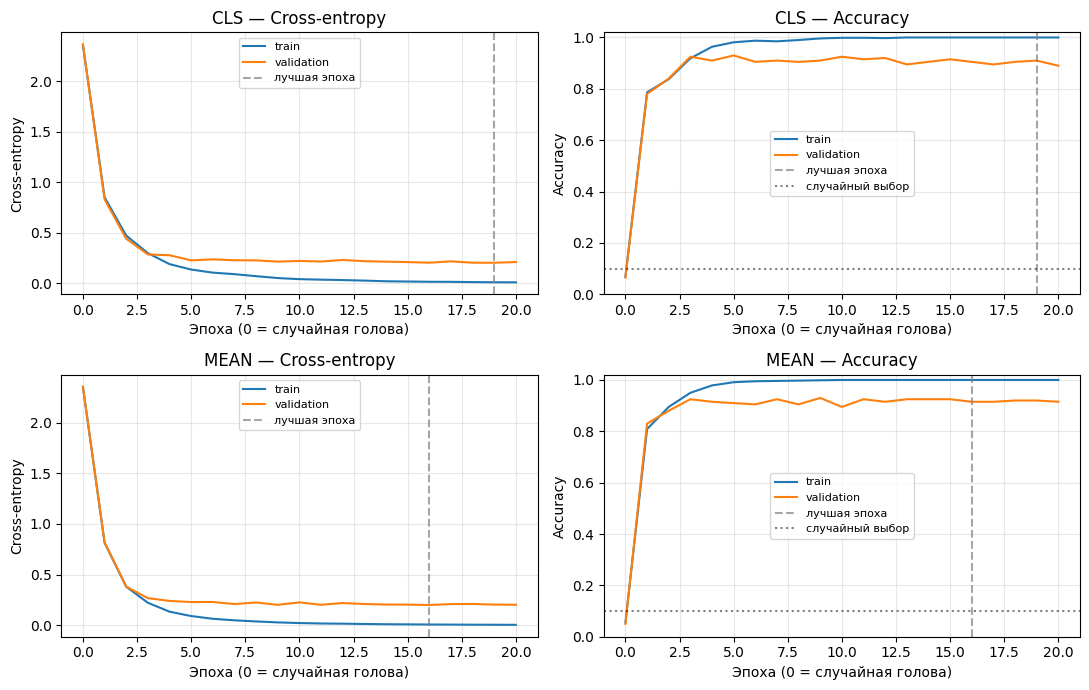

In [39]:
fig, axes = plt.subplots(len(results), 2, figsize=(11, 3.5 * len(results)), squeeze=False)
for row, (mode, result) in enumerate(results.items()):
    h = result["history"]
    for col, metric, label in [(0, "loss", "Cross-entropy"), (1, "acc", "Accuracy")]:
        ax = axes[row, col]
        ax.plot(h["epoch"], h[f"train_{metric}"], label="train")
        ax.plot(h["epoch"], h[f"val_{metric}"], label="validation")
        ax.axvline(result["best_epoch"], color="gray", ls="--", alpha=0.7, label="лучшая эпоха")
        if metric == "acc":
            ax.axhline(1 / NUM_CLASSES, color="black", ls=":", alpha=0.5, label="случайный выбор")
            ax.set_ylim(0, 1.02)
        ax.set_title(f"{mode.upper()} — {label}")
        ax.set_xlabel("Эпоха (0 = случайная голова)")
        ax.set_ylabel(label)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Финальная оценка и ошибки

Теперь фиксируем выбранную голову и оцениваем её на отложенном test. Считаем loss и accuracy; по матрице ошибок смотрим, какие типы поверхности путаются. Эта небольшая подвыборка нужна для демонстрации, а не для сравнения с результатами статей. Не выбирайте новые гиперпараметры по test: для экспериментов остаётся validation.

TEST | MEAN, epoch=16 | n=200 | loss=0.230 | accuracy=92.0%


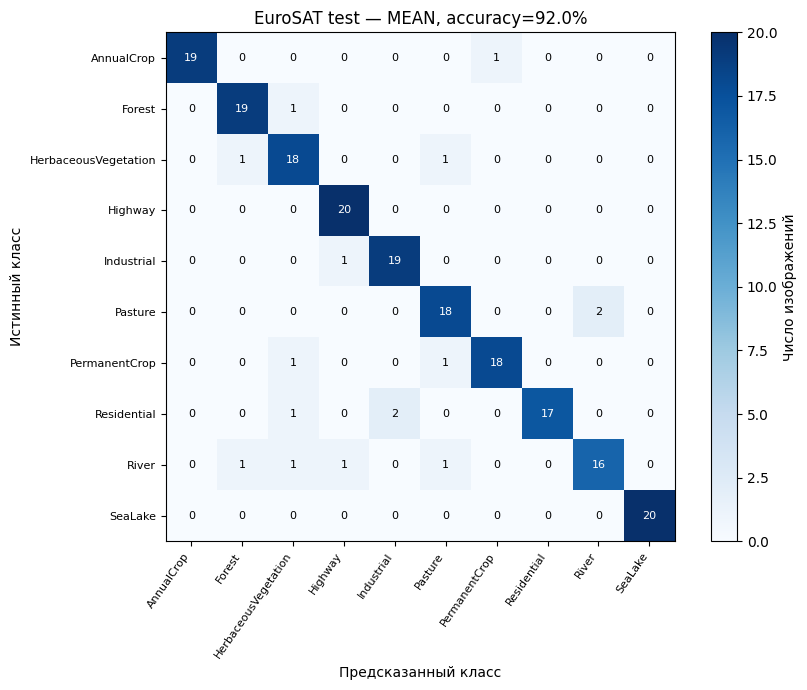

In [40]:
selected_head.eval()
with torch.no_grad():
    test_logits = selected_head(features["test"][selected_mode])
    test_y = features["test"]["labels"]
    test_loss = nn.functional.cross_entropy(test_logits, test_y).item()
    test_predictions = test_logits.argmax(dim=1)
    test_accuracy = (test_predictions == test_y).float().mean().item()
print(f"TEST | {selected_mode.upper()}, epoch={results[selected_mode]['best_epoch']} | "
      f"n={len(test_y)} | loss={test_loss:.3f} | accuracy={test_accuracy:.1%}")

cm = torch.bincount(test_y * NUM_CLASSES + test_predictions,
                    minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES).numpy()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), labels=class_names, rotation=55, ha="right", fontsize=8)
ax.set_yticks(range(NUM_CLASSES), labels=class_names, fontsize=8)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
ax.set_title(f"EuroSAT test — {selected_mode.upper()}, accuracy={test_accuracy:.1%}")
plt.colorbar(im, ax=ax, label="Число изображений")
plt.tight_layout(); plt.show()

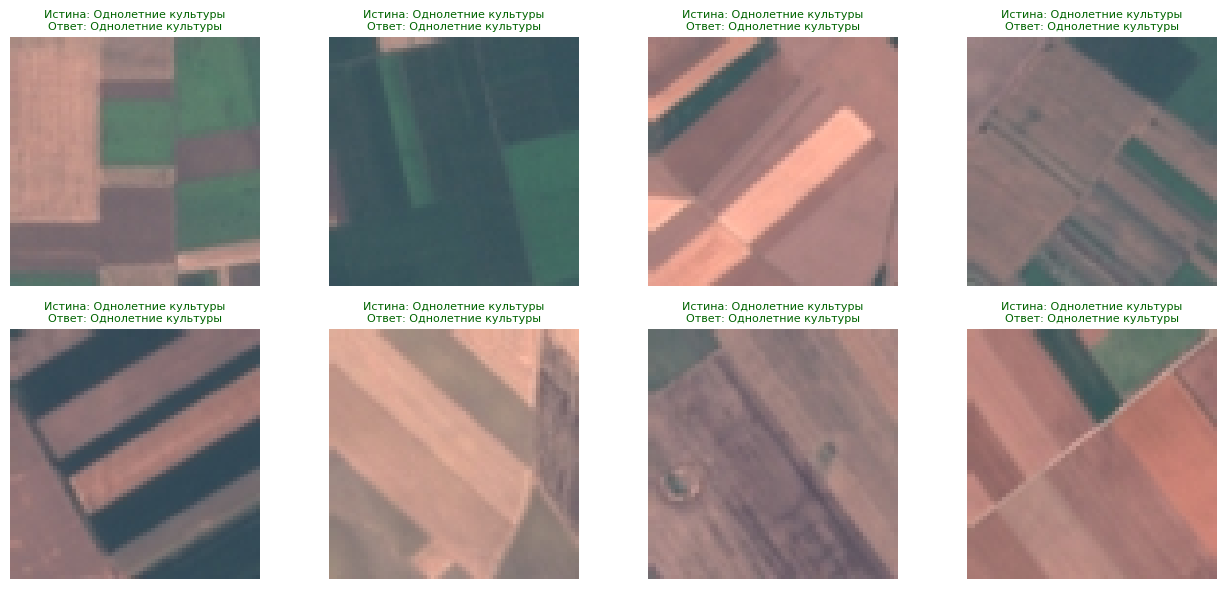

In [41]:
# Первые 8 изображений уже перемешанного test: показываем и верные ответы, и ошибки.
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for row, ax in enumerate(axes.ravel()):
    image, true_id = dataset[split_indices["test"][row]]
    pred_id = int(test_predictions[row])
    ax.imshow(image)
    ax.set_title(f"Истина: {class_titles[true_id]}\nОтвет: {class_titles[pred_id]}",
                 color="darkgreen" if pred_id == true_id else "darkred", fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

**Что видим:**

На нашей задаче EuroSAT, обучение на эмбеддинге `[CLS]` и на среднем patch-токенов показалии себя практически одинаково с точки зрения финального accuracy. Очень часто получается именно так, т.е. использование `[CLS]` и среднее эмбеддингов патчей приводит к похожим результатам. Но ы целом это зависит от данных: иногда может быть лучше `[CLS]`, а иногда — среднее патчей.


Попробуйте увеличить число обучающих примеров на каждый класс, заново обучить модель и сравнить val/test accuracy при разных объёмах данных.